<img src="./imagenes/logo_UTN.svg" align="right" width="200"/>

# **Teoría de Circuitos II**
## Informe Trabajo Practico de Laboratorio 2

---
**Profesor:** Mariano Llamedo Soria \
**Ayudante de TPs:** David Moharos \
**Jefe de TPs:** César Fuoco

**Alumno:** Valentin Dorrego\
**Curso:** R4052\
**Ciclo lectivo:** 2026  

---

**Librería CMSIS:**

El filtro digital en sí mismo es un algoritmo. En nuestro caso para simplificar la tarea vamos a instanciar funciones de la librería de procesamiento digital de arm [cmsis-dsp](https://arm-software.github.io/CMSIS_6/latest/General/index.html)

* `arm_fir_f32`
* `arm_biquad_cascade_df1_f32`

✍️ El IDE para trabajar con el mcu es el [STM32CubeIDE](https://www.st.com/en/development-tools/stm32cubeide.html)

✍️ El workspace del proyecto lo pueden descargar [acá](https://drive.google.com/file/d/1gx6FtM1LSxWALKoZYPS61EnUTvyE7NhT/view)

**Plantillas:**

| *Filtro (OPAMP)* | *Función de Aproximación* | $f_p$ | $f_s$ | $\alpha_{max}$ | $\alpha_{min}$ |
| :--- | :--- | :--- | :--- | :--- | :--- |
| A | Chebyshev | $100\text{ Hz}$ | $300\text{ Hz}$ | $1\text{ dB}$ | $60\text{ dB}$ |

<br>

| *Filtro (OPAMP)* | *Tipo* | $f_{notch}$ | **BW @ 3dB** |
| :--- | :--- | :--- | :--- |
| B | Notch | $50\text{ Hz}$ | $1\text{ Hz}$ |


**Análisis y Simulación (*Pre-Lab*)**

1. Obtener los coeficientes del filtro digital usando la función `iirdesign`
2. Simulación de la función transferencia en Python para una frecuencia de sampling **configurable**.

**Implementación (*STM32*)**

1. Compilar sin errores el proyecto en el IDE.


**Medición (*In-Lab*)**

**Las conexiones con el kit de desarrollo se detallan a continuación:**

| # PIN | DESCRIPCIÓN |
| :--- | :--- |
| CN6 - PIN 6 | GND |
| CN6 - PIN 4 | +5 VDC |
| CN8 - PIN 1 | ADC_IN |
| CN8 - PIN 3 | DAC_OUT |

---

## Resolucion
- Pre lab

*Filtro chebyshev*

Debemos determina la frecuencia de muestreo. Elejimos $fs = 5000Hz$ por lo tanto la frecuencia de Nyquist $fn=\frac{fs}{2}=2500Hz$, $fp=100Hz$ y $fs=300Hz$. Ambas se encuentran $<2500Hz$.
Por lo tanto vamos a tener de forma normalizada: $fs = \frac{1000Hz}{2500Hz}=2$, $fpass = \frac{100Hz}{2500Hz}=0.04$ y $fpass = \frac{300Hz}{2500Hz}=0.12$, entonces utilizando Python podemos determinar el ordern y los coeficientes de nuestro filtro.

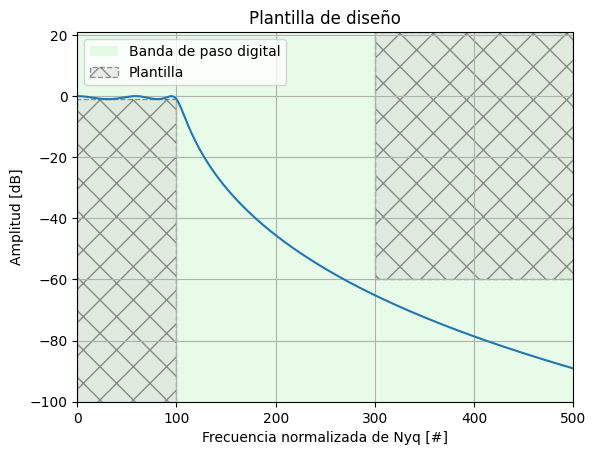

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Sat Aug 29 21:09:52 2026

@author: valen
"""

import numpy as np 
import scipy.signal as sig
import matplotlib.pyplot as plt

from pytc2.sistemas_lineales import plot_plantilla

fs = 5000

filter_type = 'lowpass'


fpass = 100
fstop = 300
ripple = 1

attenuation = 60


iir_sos= sig.iirdesign(fpass,fstop,ripple,attenuation,ftype='cheby1',output = 'sos',fs=fs)

w, h = sig.freqz_sos(iir_sos,worN=1000,fs = fs)


plt.close('all')
plt.plot(w,20*np.log10(np.abs(h)))


plt.title('Plantilla de diseño')
plt.xlabel('Frecuencia normalizada de Nyq [#]')
plt.ylabel('Amplitud [dB]')
plt.grid(which='both',axis='both')


plt.gca().set_xlim([0,500])

plot_plantilla(filter_type=filter_type, fpass=fpass,ripple=ripple,fstop=fstop,attenuation=attenuation, fs = fs)

plt.legend()

Coeficientes del filtro Chebyshev, es de orde 6, con 3 SOS en cascada.
1.157566298652619355e-10	2.315132597305238710e-10	1.157566298652619355e-10	1.000000000000000000e+00	-9.909457267193106933e-01	0.000000000000000000e+00
1.000000000000000000e+00	2.000000000000000000e+00	1.000000000000000000e+00	1.000000000000000000e+00	-1.984971659893913998e+00	9.853922899259363044e-01
1.000000000000000000e+00	1.000000000000000000e+00	0.000000000000000000e+00	1.000000000000000000e+00	-1.993423203938130994e+00	9.943958212088228610e-01


*Filtro Notch*

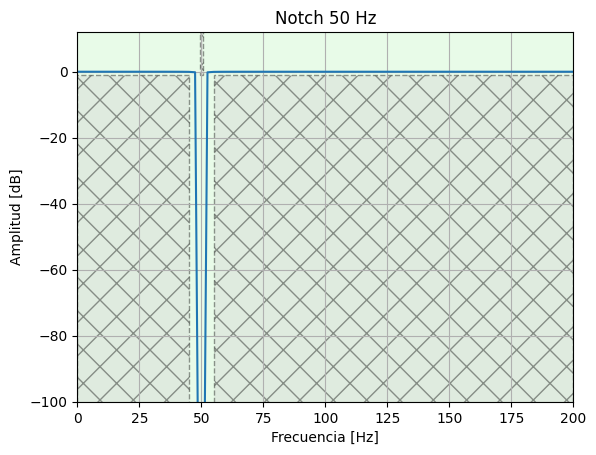

In [2]:

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import plot_plantilla

fs = 20000
f_notch = 50
bw_3db = 1

Q = f_notch / bw_3db

b, a = sig.iirnotch(f_notch, Q, fs=fs)

notch_sos = sig.tf2sos(b, a)

# Respuesta en frecuencia
w, h = sig.freqz(b, a, worN=4000, fs=fs)

plt.close('all')

# Evita log10(0)
mag_db = 20 * np.log10(np.maximum(np.abs(h), 1e-12))

plt.plot(w, mag_db)
plt.title('Notch 50 Hz')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(which='both', axis='both')
plt.xlim([0, 200])

plot_plantilla(
    filter_type='bandstop',
    fpass=(45, 55),
    ripple=1,
    fstop=(49.5, 50.5),
    attenuation=1,
    fs=fs
)

plt.show()

- Ademas de esto debemos colocar un filtro **anti-aliasing**, en la entrada del ADC.

El aliasing aparece cuando se muestrea una señal que contiene componentes de frecuencia demasiado altas.

Por el teorema de Nyquist:

$$ f_s > 2f_{max} $$

donde \(f_s\) es la frecuencia de muestreo.

En la práctica, antes del ADC se coloca un filtro pasa-bajos analógico para eliminar o atenuar las frecuencias por encima de la frecuencia de Nyquist:

$$ f_N=\frac{f_s}{2} $$

Por ejemplo, si:

$$ f_s=10\,kHz $$

entonces:

$$ f_N=5\,kHz $$

Si la señal de entrada tiene una componente de 7 kHz, esa componente puede aparecer después de la conversión como una frecuencia falsa dentro de 0–5 kHz.

El punto importante es que una vez producido el aliasing, no se puede eliminar mediante procesamiento digital, porque se perdió la información sobre cuál era la frecuencia original.

- Tambien debemos colocar un filtro **anti-imaging**, después del DAC

El DAC hace el proceso inverso: convierte muestras digitales en una señal analógica.

Pero la salida de un DAC ideal no es directamente una señal analógica perfectamente continua. Debido al muestreo, aparecen réplicas del espectro alrededor de múltiplos de la frecuencia de muestreo:

$$ \pm f_s,\quad \pm 2f_s,\quad \pm3f_s,\ldots $$

Por ejemplo, si tenemos una señal cuya banda llega hasta 4 kHz y:

$$ f_s=10\,kHz $$

el espectro deseado está entre aproximadamente:

$$ -4\,kHz \quad \text{y} \quad +4\,kHz $$

pero también aparecen imágenes alrededor de \(10\,kHz\), \(20\,kHz\), etc.

Entonces se coloca un filtro pasa-bajos después del DAC para eliminar esas imágenes:

Anti-imaging = eliminar las réplicas espectrales producidas por el proceso de reconstrucción mediante el DAC.

Para estos filtros utilizamos dos *filtros pasabajos* RC, que es lo mas sensillo debido a que vamos a necesitar meterle un offset a nuestra señal para que se encuentr entre 0V y 3.3V que es el rango en el que trabaja el ADC de la nucleo F446.

Fijamos el capacitor en $10nF$ y la resistencia con un valor de $R=15k$ para tener un $\omega_0 = 2\pi 1kHz$

<div align="center">
    <img src="imagenes/Tpl2/1.png" width="400">
    <figcaption>Figura 1: Filtro anti-aliasing y Anti-imaging.</figcaption>
</div>


- In-Lab

Cargamos los coeficientes generados en python al codigo otorgado por la catredra y obtuvimos los siguientes resultados:

<div align="center">
    <img src="imagenes/Tpl2/7.png" width="400">
    <figcaption>Figura 2: Mesa de trabajo.</figcaption>
</div>


*Notch*
<div align="center">
    <img src="imagenes/Tpl2/2.png" width="400">
    <figcaption>Figura 3: Diagrama de magnitud del filtro Notch.</figcaption>
</div>

<div align="center">
    <img src="imagenes/Tpl2/3.png" width="400">
    <figcaption>Figura 4: Diagrama Fase del filtro Notch.</figcaption>
</div>

*Fir pasabajos*

<div align="center">
    <img src="imagenes/Tpl2/4.png" width="400">
    <figcaption>Figura 5: Diagrama de magnitud del filtro Fir.</figcaption>
</div>

<div align="center">
    <img src="imagenes/Tpl2/5.png" width="400">
    <figcaption>Figura 6: Diagrama de fase del filtro Fir.</figcaption>
</div>

*IRR pasabajos*
<div align="center">
    <img src="imagenes/Tpl2/6.png" width="400">
    <figcaption>Figura 7: Diagrama de Modulo del filtro IRR.</figcaption>
</div>

---

## Conclusiones
En este laboratorio se pudo aplicar el diseño e implementación de filtros digitales, partiendo de las especificaciones dadas para los filtros y obteniendo sus coeficientes mediante herramientas de Python. Se analizó la respuesta en frecuencia de los filtros para verificar que cumplieran, dentro de lo esperado, con las frecuencias de paso, detención y atenuación especificadas.

Además, se trabajó con diferentes estructuras de implementación, como filtros FIR y filtros IIR mediante secciones de segundo orden, y se utilizó la librería CMSIS-DSP para facilitar su ejecución en el microcontrolador STM32. Finalmente, la implementación permitió relacionar el diseño realizado en software con su aplicación sobre el hardware, utilizando el ADC como entrada y el DAC como salida.

En general, el laboratorio permitió comprender el proceso completo de diseño, simulación e implementación de un filtro digital, observando cómo las características definidas inicialmente se reflejan en el comportamiento del sistema real.